In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset = pd.read_csv("powerplant_data.csv")

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
dataset.shape

(9568, 5)

In [5]:
dataset.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
dataset.sample(10)

,AT,V,AP,RH,PE
2324,10.75,45.00,1023.68,89.37,481.96
1560,24.42,65.94,1011.25,65.04,439.63
4929,24.38,47.01,1015.17,68.96,454.85
5965,22.39,48.14,1014.56,64.31,448.58
1981,21.99,57.50,1015.87,80.72,446.96
2403,18.67,44.06,1017.13,77.18,454.51
2667,8.50,39.16,1014.10,86.64,485.76
541,23.48,60.23,1011.91,79.48,437.44
595,24.01,65.46,1014.17,43.02,443.81
7587,15.08,42.77,1018.43,73.19,461.68


In [7]:
x = dataset.drop("PE",axis=1)
y = dataset["PE"]

In [8]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,y,random_state=42,
    test_size=0.3)

In [9]:
x_train.shape

(6697, 4)

In [10]:
x_test.shape

(2871, 4)

In [11]:
from sklearn.preprocessing import StandardScaler

sclr = StandardScaler()

x_train_scaled = sclr.fit_transform(x_train)
x_test_scaled = sclr.fit_transform(x_test)

In [12]:
import torch
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_scaled,dtype = torch.float32) #numpy to tensor
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1) #dataframe to tensors


x_test_tensor = torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

ModuleNotFoundError: No module named 'torch'

In [ ]:
x_test_tensor.shape

torch.Size([2871, 4])

In [ ]:
from torch.utils.data import TensorDataset,DataLoader

#given by gpt 
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_dataloader = DataLoader(train_dataset,batch_size =32 , shuffle = True) # define dataloader
test_dataloader = DataLoader(test_dataset,batch_size =32 , shuffle = True)

# define ANN model

In [ ]:
class ANN(nn.Module):
    def __init__(self): #constructor
        super(ANN, self).__init__() #Call the constructor of the parent class

        self.model = nn.Sequential(
            
            #1 layer(input layer)

            nn.Linear(x_train.shape[1],6), #inputfeature and output feature
            nn.ReLU(),

            #2nd layer(hidden layer)
            nn.Linear(6,6),
            nn.ReLU(),

            #output layer
            nn.Linear(6,1)

        )

    def forward(self,x): #forward propagation
        return self.model(x)
        
        


In [ ]:
import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),)

In [ ]:
epochs = 50
train_losses = []
val_losses = []

best_val_loss = float("inf") # infinite

for epoch in range(epochs):


    model.train()
    running_loss = 0.0

    for xb, yb in train_dataloader:
        optimizer.zero_grad()
        
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_dataloader)
    train_losses.append(epoch_train_loss)

    #  VALIDATION
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for xb, yb in test_dataloader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_dataloader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} ==> Train Loss = {epoch_train_loss:.4f}, Val Loss = {epoch_val_loss:.4f}")

  
    if epoch_val_loss < best_val_loss: 
        best_val_loss = epoch_val_loss ## storing best model
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1/50 ==> Train Loss = 205342.4773, Val Loss = 202651.7333
Epoch 2/50 ==> Train Loss = 195363.3374, Val Loss = 183666.7759
Epoch 3/50 ==> Train Loss = 161647.1702, Val Loss = 133375.5589
Epoch 4/50 ==> Train Loss = 100230.6856, Val Loss = 68315.7036
Epoch 5/50 ==> Train Loss = 45979.1247, Val Loss = 29671.2640
Epoch 6/50 ==> Train Loss = 23046.5840, Val Loss = 18813.2672
Epoch 7/50 ==> Train Loss = 17070.7470, Val Loss = 15243.7519
Epoch 8/50 ==> Train Loss = 13904.0142, Val Loss = 12334.3065
Epoch 9/50 ==> Train Loss = 11105.3817, Val Loss = 9620.5476
Epoch 10/50 ==> Train Loss = 8460.4623, Val Loss = 7146.4655
Epoch 11/50 ==> Train Loss = 6125.3158, Val Loss = 5022.4674
Epoch 12/50 ==> Train Loss = 4228.6999, Val Loss = 3363.3013
Epoch 13/50 ==> Train Loss = 2761.2651, Val Loss = 2148.4234
Epoch 14/50 ==> Train Loss = 1768.9825, Val Loss = 1369.2487
Epoch 15/50 ==> Train Loss = 1141.8547, Val Loss = 893.3920
Epoch 16/50 ==> Train Loss = 756.9353, Val Loss = 597.4392
Epoch 17/50 

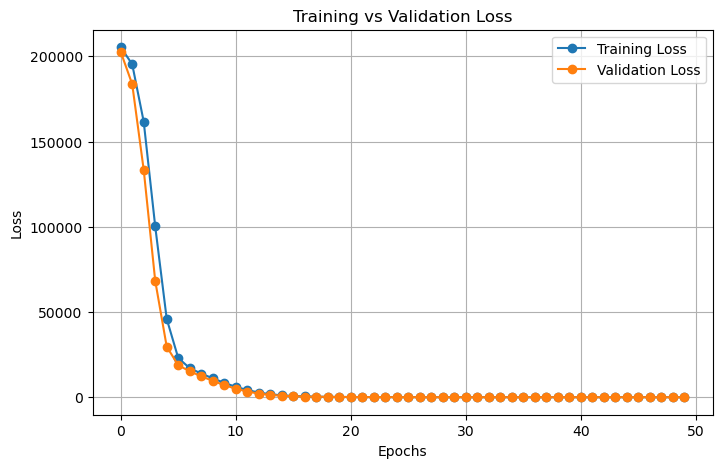

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", marker='o')
plt.plot(val_losses, label="Validation Loss", marker='o')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [ ]:
# loading the best model 
model.load_state_dict(torch.load("best_model.pt")) #

<All keys matched successfully>

In [ ]:
# Evaluate our model

model.eval()
with torch.no_grad():
    train_pred = model(x_train_tensor)
    test_pred  = model(x_test_tensor)

    train_mse_loss = criterion(train_pred,y_train_tensor)
    test_mse_loss = criterion(test_pred,y_test_tensor)

print("train mse : ",train_mse_loss)
print("test mse :",test_mse_loss) 

train mse :  tensor(20.8549)
test mse : tensor(19.5282)


In [ ]:
from sklearn.metrics import r2_score

print("r2 score = ", r2_score(y_test,test_pred))

r2 score =  0.9321859365960207


In [ ]:
y_test


2513    433.27
9411    438.16
8745    458.42
9085    480.82
4950    441.41
         ...  
981     480.31
4694    446.77
1407    454.66
535     483.77
5327    441.51
Name: PE, Length: 2871, dtype: float64

In [ ]:
test_mse_loss

tensor(19.5282)